In [ ]:
!nvidia-smi

Mon Mar 30 18:28:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
%%writefile main.cu

Writing main.cu


In [8]:
!nvcc -std=c++17 -arch=sm_75 main.cu -o app -DMATRIX_TYPE=int

In [9]:
!./app


Matrix size: 100x100
Type: int
CPU avg: 6.48947 ms
GPU avg: 0.058592 ms
Speedup: 110.757
Correct: YES

Matrix size: 500x500
Type: int
CPU avg: 828.152 ms
GPU avg: 0.789045 ms
Speedup: 1049.56
Correct: YES

Matrix size: 1000x1000
Type: int
CPU avg: 7516 ms
GPU avg: 7.10598 ms
Speedup: 1057.7
Correct: YES

Matrix size: 1500x1500
Type: int
CPU avg: 32759.5 ms
GPU avg: 27.4593 ms
Speedup: 1193.02
Correct: YES

Matrix size: 2000x2000
Type: int
CPU avg: 89084.2 ms
GPU avg: 58.7985 ms
Speedup: 1515.07
Correct: YES

Results saved to results.csv


In [10]:
!nvcc -std=c++17 -arch=sm_75 main.cu -o app -DMATRIX_TYPE=float

In [11]:
!./app


Matrix size: 100x100
Type: float
CPU avg: 9.36322 ms
GPU avg: 0.065216 ms
Speedup: 143.572
Correct: YES

Matrix size: 500x500
Type: float
CPU avg: 936.132 ms
GPU avg: 0.891253 ms
Speedup: 1050.35
Correct: YES

Matrix size: 1000x1000
Type: float
CPU avg: 8394.75 ms
GPU avg: 7.10821 ms
Speedup: 1180.99
Correct: YES

Matrix size: 1500x1500
Type: float
CPU avg: 37876.7 ms
GPU avg: 27.4575 ms
Speedup: 1379.46
Correct: YES

Matrix size: 2000x2000
Type: float
CPU avg: 102785 ms
GPU avg: 58.7973 ms
Speedup: 1748.12
Correct: YES

Results saved to results.csv


In [12]:
!nvcc -std=c++17 -arch=sm_75 main.cu -o app -DMATRIX_TYPE=double

In [13]:
!./app


Matrix size: 100x100
Type: double
CPU avg: 7.3777 ms
GPU avg: 0.0878293 ms
Speedup: 84.0004
Correct: YES

Matrix size: 500x500
Type: double
CPU avg: 1020.13 ms
GPU avg: 2.88825 ms
Speedup: 353.199
Correct: YES

Matrix size: 1000x1000
Type: double
CPU avg: 10361 ms
GPU avg: 22.4025 ms
Speedup: 462.491
Correct: YES

Matrix size: 1500x1500
Type: double
CPU avg: 44606.2 ms
GPU avg: 75.0043 ms
Speedup: 594.715
Correct: YES

Matrix size: 2000x2000
Type: double
CPU avg: 128695 ms
GPU avg: 171.193 ms
Speedup: 751.752
Correct: YES

Results saved to results.csv


In [14]:
from google.colab import files
files.download("results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("results.csv")
types = df['type'].unique()
print(df.head())

  type  size  cpu_time_ms  gpu_time_ms   speedup
0  int   100      6.48947     0.058592   110.757
1  int   500    828.15200     0.789045  1049.560
2  int  1000   7516.00000     7.105980  1057.700
3  int  1500  32759.50000    27.459300  1193.020
4  int  2000  89084.20000    58.798500  1515.070


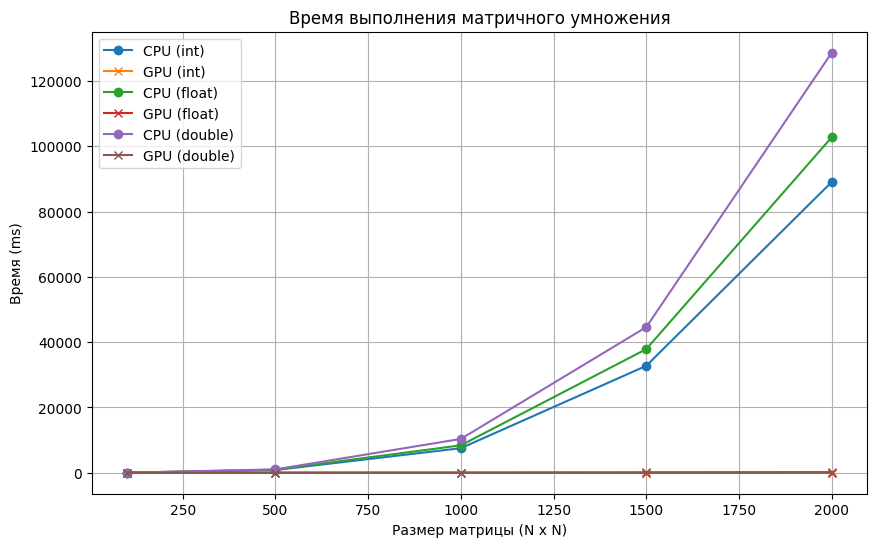

In [16]:
plt.figure(figsize=(10,6))
for t in types:
    subset = df[df['type'] == t]
    plt.plot(subset['size'], subset['cpu_time_ms'], marker='o', label=f'CPU ({t})')
    plt.plot(subset['size'], subset['gpu_time_ms'], marker='x', label=f'GPU ({t})')

plt.title("Время выполнения матричного умножения")
plt.xlabel("Размер матрицы (N x N)")
plt.ylabel("Время (ms)")
plt.legend()
plt.grid(True)
plt.show()

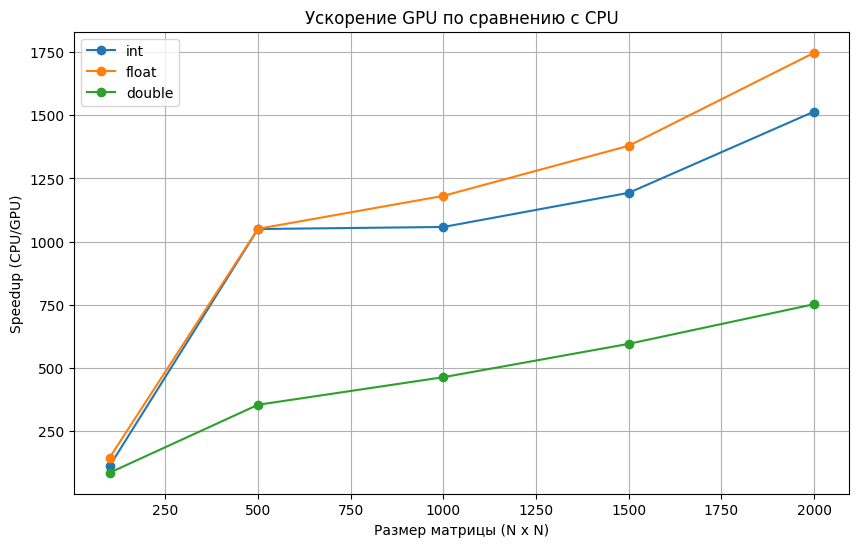

In [17]:
plt.figure(figsize=(10,6))
for t in types:
    subset = df[df['type'] == t]
    plt.plot(subset['size'], subset['speedup'], marker='o', label=f'{t}')

plt.title("Ускорение GPU по сравнению с CPU")
plt.xlabel("Размер матрицы (N x N)")
plt.ylabel("Speedup (CPU/GPU)")
plt.legend()
plt.grid(True)
plt.show()